In [71]:
import numpy as np 
import os
import pandas as pd
import re 
import matplotlib.pyplot as plt
are_arr=[]
pop_arr=[]
cities_are=[]
cities_pop=[]
dir_pop="/Users/mika/Documents/DATA/src/population"
dir_area="/Users/mika/Documents/DATA/src/area"

pat=r'_(.+)\.csv'
pat=re.compile(pat)

for file in os.listdir(dir_pop):

    file_dir=dir_pop+"/"+file
    df=pd.read_csv(file_dir)

    pop_arr.append(df.values[:,1])

    city=pat.search(file).group(1)
    cities_pop.append(city)
    
df_pop=pd.DataFrame({'name':cities_pop,'pop':pop_arr})
df_pop=df_pop.sort_values('name')
 

for file in os.listdir(dir_area):

    file_dir=dir_area+"/"+file
    df=pd.read_csv(file_dir)

    are_arr.append(df.values[:,1])

    city=pat.search(file).group(1)
    cities_are.append(city)

df_area=pd.DataFrame({'name':cities_are,'are':are_arr})
df_area=df_area.sort_values('name')



df_all = pd.merge(df_pop, df_area, on='name')








   
print(df_all)



              name                                                pop  \
0          Atlanta  [217155.11, 221044.94, 226367.46, 229758.39, 2...   
1          Bangkok  [6950566.48, 7339370.01, 7729419.62, 8276664.5...   
2          Beijing  [7715155.0, 8408441.0, 9135697.0, 9759883.0, 1...   
3        Bengalore  [4191066.48, 4274830.98, 4500218.18, 4756152.2...   
4            Cairo  [8529929, 8719723, 8849238, 9023893, 9131961, ...   
5        Changzhou  [691981.44, 755135.44, 977021.88, 1107389.0, 8...   
6   Chengdu Deyang  [876488.69, 982617.81, 1061955.75, 1184420.25,...   
7   Guatemala City  [1167518.25, 1176892.25, 1195414.0, 1198227.0,...   
8     Johannesburg  [2690303.56, 2800429.66, 2892315.91, 3002528.5...   
9          Kolkata  [10594465.5, 10811500.0, 10959589.0, 11033630....   
10       Las Vegas  [837496.2, 893624.31, 936545.14, 975114.73, 10...   
11          London  [7696330.48, 7803425.54, 7902524.49, 8006301.6...   
12     Mexico City  [11140219.76, 11220759.17, 1132

/var/folders/44/_fjq_3dd6yd8jl0b2wp5v85m0000gn/T/ipykernel_83679/2424951519.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20')  # tab20 has 20 distinct colors


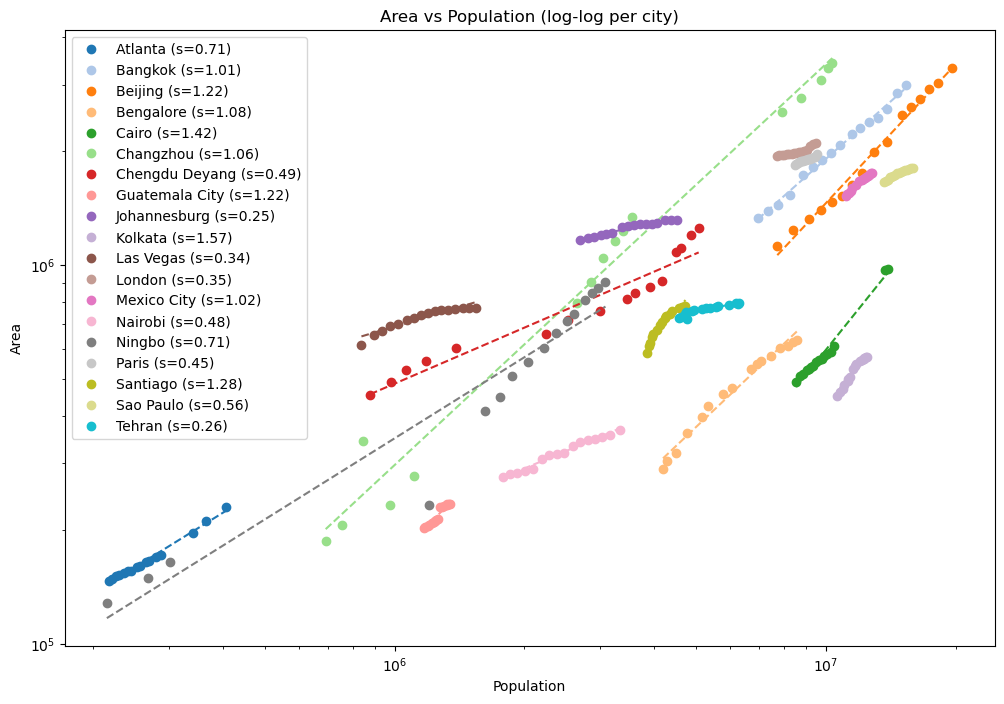

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

slope_arr = []

plt.figure(figsize=(12,8))

# Create a colormap with 19 distinct colors
cmap = get_cmap('tab20')  # tab20 has 20 distinct colors
colors = [cmap(i) for i in range(19)]

for i, (_, row) in enumerate(df_all.iterrows()):
    x = np.array(row['pop'])
    y = np.array(row['are'])

    # remove non-positive values (important for log)
    mask = (x > 0) & (y > 0)
    x = x[mask]
    y = y[mask]

    # log-log regression
    logx = np.log10(x)
    logy = np.log10(y)
    slope, intercept = np.polyfit(logx, logy, 1)
    slope_arr.append(slope)

    # fit curve
    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = 10**intercept * x_fit**slope

    # select color (cycle through 19 if more cities)
    color = colors[i % 19]

    # label includes city + slope
    label = f"{row['name']} (s={slope:.2f})"

    # plot data + fit
    plt.plot(x, y, marker='o', linestyle='', color=color, label=label)
    plt.plot(x_fit, y_fit, linestyle='--', color=color)

# log scales
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Population')
plt.ylabel('Area')
plt.title('Area vs Population (log-log per city)')
plt.legend()
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 [Text(0, 0, 'Atlanta'),
  Text(1, 0, 'Bangkok'),
  Text(2, 0, 'Beijing'),
  Text(3, 0, 'Bengalore'),
  Text(4, 0, 'Cairo'),
  Text(5, 0, 'Changzhou'),
  Text(6, 0, 'Chengdu Deyang'),
  Text(7, 0, 'Guatemala City'),
  Text(8, 0, 'Johannesburg'),
  Text(9, 0, 'Kolkata'),
  Text(10, 0, 'Las Vegas'),
  Text(11, 0, 'London'),
  Text(12, 0, 'Mexico City'),
  Text(13, 0, 'Nairobi'),
  Text(14, 0, 'Ningbo'),
  Text(15, 0, 'Paris'),
  Text(16, 0, 'Santiago'),
  Text(17, 0, 'Sao Paulo'),
  Text(18, 0, 'Tehran')])

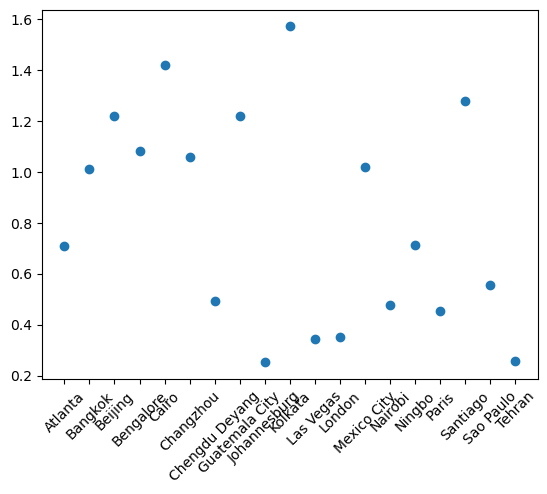

In [70]:
plt.figure()
plt.scatter(df_all['name'],slope_arr)
plt.xticks(rotation=45)